# SEEDS - 3 - Potential Future CGSs Sites Search

This notebook combines and formalizes data to identify potential future Community Growing Schemes (CGSs) sites in **Leeds**. 

The workflow is designed to be adaptable for any UK local authority, which is selected at the beginning of the notebook. However, as this project focuses on Leeds, several datasets are sourced from the Leeds City Council and other Leeds-based organisations, making parts of the analysis project-specific.

Where possible, the notebook automatically retrieves the most up-to-date available data. Some datasets are however static and have not been updated for several years, these must thus be dowloaded manually.

In [291]:
pip install matplotlib mapclassify geopandas numpy scipy folium plotly fiona osmnx hashlib sklearn

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement hashlib (from versions: 20081119)
ERROR: No matching distribution found for hashlib


In [292]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import os
import fiona
import hashlib
import folium
import mapclassify

In [293]:
#Choose Local Authority to work with
LOCAL_AUTHORITY_NAME = 'Leeds' 

output_file = f'output_{LOCAL_AUTHORITY_NAME}.gpkg'

## 1- Define Local Authority Boundaries

The UK local authorities boundaries data was downloaded from [geoportal](https://geoportal.statistics.gov.uk/datasets/ons::local-authority-districts-may-2024-boundaries-uk-bfe-2/explore?location=53.495068%2C-0.354857%2C7).
The UK data is subsetted to only include the boundaries of the local authority chosen at the start, in the case of this study Leeds is chosen.

In [294]:
# Define data folder path
DATA_DIR = r'C:\Users\qxnq723\Desktop\Project_2\Datasets'

# UK local authorities file path
UK_LAD_PATH = f"{DATA_DIR}\Local_Authority_Districts_May_2024_Boundaries_UK_BFE_6583563793708892075\LAD_MAY_2024_UK_BFE.shp"

print(f"Configured for: {LOCAL_AUTHORITY_NAME}")
print(f"Data directory: {DATA_DIR}")

Configured for: Leeds
Data directory: C:\Users\qxnq723\Desktop\Project_2\Datasets


In [295]:
# Load UK Local Authority District boundaries
print("Loading UK Local Authority District boundaries...")
LAD_2024 = gpd.read_file(UK_LAD_PATH)

print(f"Loaded {len(LAD_2024)} local authority districts")
print(f"Available LADs include: {sorted(LAD_2024['LAD24NM'].unique())[:10]}...")

# Check if our chosen LAD exists 
if LOCAL_AUTHORITY_NAME in LAD_2024['LAD24NM'].values:
    print(f"Found {LOCAL_AUTHORITY_NAME} in the dataset")
    target_lad = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
    print(f"Area: {target_lad.to_crs('EPSG:27700').geometry.area.iloc[0]/1000000:.2f} km²")
else:
    print(f"{LOCAL_AUTHORITY_NAME} not found in dataset")
    print("Available LADs:", sorted(LAD_2024['LAD24NM'].unique()))

Loading UK Local Authority District boundaries...
Loaded 361 local authority districts
Available LADs include: ['Aberdeen City', 'Aberdeenshire', 'Adur', 'Amber Valley', 'Angus', 'Antrim and Newtownabbey', 'Ards and North Down', 'Argyll and Bute', 'Armagh City, Banbridge and Craigavon', 'Arun']...
Found Leeds in the dataset
Area: 551.70 km²


Isolate the outline of the chosen Local Authority (in this case Leeds), to clip other datasets to it.

<Axes: >

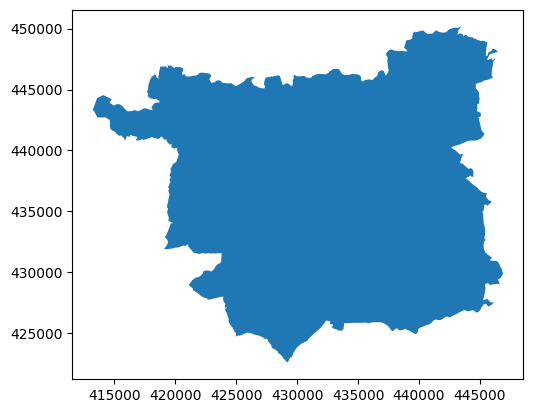

In [296]:
#Keep only chosen LA and plot it
chosen_LA = LAD_2024[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME]
chosen_LA.plot()

In [297]:
#Check CRS
print(chosen_LA.crs)

EPSG:27700


In [298]:
#Create outline of chosen LA
chosen_LA['outline'] = 1
LA_outline = chosen_LA.dissolve(by= 'outline')

A function is created to subset datasets to the chosen local authority boundaries.

In [299]:
#Create function to subset data to the chosen LA
def subset_to_LAD(LAD_gdf, LAD_column_name, LAD_name, data_to_subset):
    """
    Subset a greenspace (or similar file) to only include greenspaces 
    within a chosen local authority.
    
    Parameters
    ----------
    LAD_gdf : geopandas.GeoDataFrame
        GeoDataFrame containing local authority district boundaries
    LAD_column_name : str
        Name of the column containing LAD names
    LAD_name : str
        Name of the specific LAD to subset to
    data_to_subset : geopandas.GeoDataFrame
        Data to be subset to the chosen LAD
        
    Returns
    -------
    geopandas.GeoDataFrame
        Data subset to only include features within the chosen LAD
    """
    chosen_LAD = LAD_gdf.loc[LAD_gdf[LAD_column_name] == LAD_name, :]
    chosen_LAD = chosen_LAD.to_crs(data_to_subset.crs)
    data_subset_to_LAD = data_to_subset[data_to_subset.within(chosen_LAD.union_all())]
    return data_subset_to_LAD

**The rest of the notebook collects and cleans different datasets to create individual files for each layer that will be added to the 'Imagining Future Growing Spaces' page of the SEEDS dashboard.**

## 2- Creating the Brownfields layer - Leeds City Council

### A- Web Scraping

The polygons of brownfields in Leeds are scraped from the Leeds City Council ArcGis webpage.

In [300]:
import requests
from shapely.geometry import Polygon, MultiPolygon

url= "https://mapservices.leeds.gov.uk/arcgis/rest/services/Public/Strategic_Planning/MapServer/14/query"

headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #retrun all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'json', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    data = requests.get(url, params= params, headers= headers).json()

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        row= f['attributes']
        geom = f.get('geometry')
    
        #Convert ArcGis data to Python geoemtries
        if geom and 'rings' in geom:
            try:
                row['geometry'] = Polygon(geom['rings'][0])
            except Exception:
                row['geometry'] = None
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
LCC_brownfields = pd.DataFrame(all_rows)
LCC_brownfields = gpd.GeoDataFrame(LCC_brownfields, geometry='geometry', crs='EPSG:27700')

print('Done:', len(LCC_brownfields), 'brownfields in Leeds')

Fetched 2000 records
Fetched 4000 records
Done: 2602 brownfields in Leeds


In [301]:
#Check
LCC_brownfields.info()
print(LCC_brownfields.crs)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2602 entries, 0 to 2601
Data columns (total 42 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID_1        2602 non-null   int64   
 1   OBJECTID          1998 non-null   float64 
 2   BOUNDNUM          2602 non-null   str     
 3   YEAR              2602 non-null   float64 
 4   ORGANISATI        2602 non-null   str     
 5   ORGANISA_1        2602 non-null   str     
 6   SITEREFERE        2602 non-null   str     
 7   PREVIOUSLY        2602 non-null   str     
 8   SITENAMEAD        2602 non-null   str     
 9   SITEPLANUR        2602 non-null   str     
 10  COORDINATE        2602 non-null   str     
 11  GEOX              2602 non-null   float64 
 12  GEOY              2602 non-null   float64 
 13  HECTARES          2602 non-null   float64 
 14  OWNERSHIPS        2602 non-null   str     
 15  DELIVERABL        2602 non-null   str     
 16  PLANNINGST      

In [302]:
LCC_brownfields['OWNERSHIPS'].value_counts()

OWNERSHIPS
not owned by a public authority    1727
owned by a public authority         402
Unknown                             265
mixed ownership                     131
Public ownership                     77
Name: count, dtype: int64

In [303]:
#Only the publicly owned brownfields are kept
keep = ['owned by a public authority', 'mixed ownership', 'Public ownership']
LCC_brownfields = LCC_brownfields[LCC_brownfields['OWNERSHIPS'].isin(keep)]

In [304]:
LCC_brownfields.head()

,OBJECTID_1,OBJECTID,BOUNDNUM,YEAR,ORGANISATI,ORGANISA_1,SITEREFERE,PREVIOUSLY,SITENAMEAD,SITEPLANUR,...,SITEREFE_1,EASTING,NORTHING,SORT,BOUNDREF,SE_ANNO_CAD_DATA,GLOBALID,SHAPE.AREA,SHAPE.LEN,geometry
3,4,125.0,SHL002281,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00228,,"""Ardsley Sidings East Ardsley""",,...,494,430853.0,426235.0,20160494.0,SHL002281,None,{69F3C83D-915C-4544-9D0B-AC4D24C1BA8A},0,0,"POLYGON ((430741.567 426377.647, 430744.212 42..."
8,9,367.0,SHL001711,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00171,,"""Cropper Gate LS1""",,...,402,429170.0,433556.0,20160402.0,SHL001711,None,{4F9A3F9C-8F26-44CE-993F-FEBF3FBF3ABA},0,0,"POLYGON ((429177.475 433531.556, 429174.756 43..."
16,17,616.0,SHL000732,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00073,,"""Lowfold, East Street, Leeds, LS9 8""",,...,207,431359.0,432622.0,20160207.0,SHL000732,None,{C86D8B29-A8A9-42FF-B39C-4595D117B2A8},0,0,"POLYGON ((431245.66 432738.84, 431247.43 43274..."
20,21,712.0,SHL001631,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00163,,"""Beckhill Garth/Approach""",,...,383,429149.0,436892.0,20160383.0,SHL001631,None,{85BE61C7-5DB0-4FE6-B552-250C958F4AA1},0,0,"POLYGON ((429041.409 436841.334, 429041.6 4368..."
22,23,807.0,SHL003591,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00359,,"""South Parkway/york Road Depot LS14""",,...,816,435801.0,435699.0,20160816.0,SHL003591,None,{BD013A30-EC38-4450-90D9-9FAD4F8B15AF},0,0,"POLYGON ((435736.191 435714.073, 435736.507 43..."


In [305]:
print(LCC_brownfields.is_valid.value_counts())
#Fix any invalid geometries
LCC_brownfields['geometry'] = LCC_brownfields.buffer(0)
print(LCC_brownfields.is_valid.value_counts())

True     605
False      5
Name: count, dtype: int64
True    610
Name: count, dtype: int64


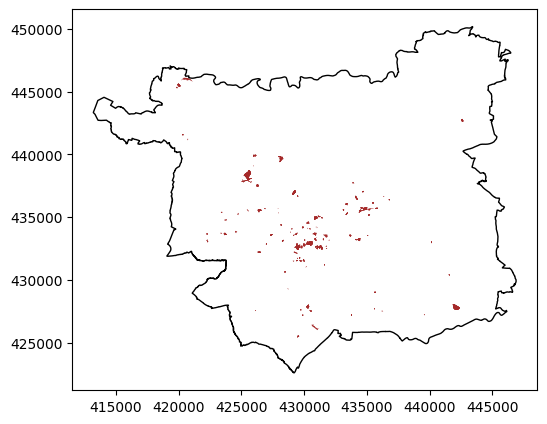

In [306]:
fig , ax = plt.subplots(figsize=(6, 6))

#Plot outline first
LA_outline.plot(
    ax= ax,
    facecolor= 'none',
    edgecolor='black',
    linewidth=1
)

#Plot brown fields
LCC_brownfields.plot(
    ax=ax,
    color='brown'
)

plt.show()

In [307]:
#Convert CRS to 4326 for mapping on dashboard
print(LCC_brownfields.crs)
LCC_brownfields = LCC_brownfields.to_crs(4326)
print(LCC_brownfields.crs)

EPSG:27700
EPSG:4326


In [308]:
LCC_brownfields.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 610 entries, 3 to 2582
Data columns (total 42 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   OBJECTID_1        610 non-null    int64   
 1   OBJECTID          476 non-null    float64 
 2   BOUNDNUM          610 non-null    str     
 3   YEAR              610 non-null    float64 
 4   ORGANISATI        610 non-null    str     
 5   ORGANISA_1        610 non-null    str     
 6   SITEREFERE        610 non-null    str     
 7   PREVIOUSLY        610 non-null    str     
 8   SITENAMEAD        610 non-null    str     
 9   SITEPLANUR        610 non-null    str     
 10  COORDINATE        610 non-null    str     
 11  GEOX              610 non-null    float64 
 12  GEOY              610 non-null    float64 
 13  HECTARES          610 non-null    float64 
 14  OWNERSHIPS        610 non-null    str     
 15  DELIVERABL        610 non-null    str     
 16  PLANNINGST        610 

In [309]:
LCC_brownfields["DEVELOPMEN"].unique()

<StringArray>
[                                                                                                                                                                                                                                                             ' ',
                                                                                                                                                                       'Change of use of first floor warehouse to five flats and alterations including extension',
                                                                                                                                       'Extension of time planning application 20/207/05/FU (10-28 storey block-272 flats offices, A3 use and basement parking).',
                                                                                                                                                                                                    '312 dwelling

In [310]:
LCC_brownfields.head()

,OBJECTID_1,OBJECTID,BOUNDNUM,YEAR,ORGANISATI,ORGANISA_1,SITEREFERE,PREVIOUSLY,SITENAMEAD,SITEPLANUR,...,SITEREFE_1,EASTING,NORTHING,SORT,BOUNDREF,SE_ANNO_CAD_DATA,GLOBALID,SHAPE.AREA,SHAPE.LEN,geometry
3,4,125.0,SHL002281,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00228,,"""Ardsley Sidings East Ardsley""",,...,494,430853.0,426235.0,20160494.0,SHL002281,None,{69F3C83D-915C-4544-9D0B-AC4D24C1BA8A},0,0,"POLYGON ((-1.53549 53.73289, -1.53545 53.73282..."
8,9,367.0,SHL001711,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00171,,"""Cropper Gate LS1""",,...,402,429170.0,433556.0,20160402.0,SHL001711,None,{4F9A3F9C-8F26-44CE-993F-FEBF3FBF3ABA},0,0,"POLYGON ((-1.55852 53.79728, -1.55856 53.79725..."
16,17,616.0,SHL000732,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00073,,"""Lowfold, East Street, Leeds, LS9 8""",,...,207,431359.0,432622.0,20160207.0,SHL000732,None,{C86D8B29-A8A9-42FF-B39C-4595D117B2A8},0,0,"POLYGON ((-1.5272 53.79003, -1.52718 53.79005,..."
20,21,712.0,SHL001631,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00163,,"""Beckhill Garth/Approach""",,...,383,429149.0,436892.0,20160383.0,SHL001631,None,{85BE61C7-5DB0-4FE6-B552-250C958F4AA1},0,0,"POLYGON ((-1.56028 53.82703, -1.56027 53.82703..."
22,23,807.0,SHL003591,2016.0,http://opendatacommunities.org/id/metropolitan...,Leeds City Council,SHL00359,,"""South Parkway/york Road Depot LS14""",,...,816,435801.0,435699.0,20160816.0,SHL003591,None,{BD013A30-EC38-4450-90D9-9FAD4F8B15AF},0,0,"POLYGON ((-1.4587 53.81649, -1.4587 53.81649, ..."


In [311]:
#Keep only the information required for dashboard mapping
LCC_brownfields = LCC_brownfields[["YEAR",
                                   "ORGANISATI",
                                    "ORGANISA_1",
                                    "SITENAMEAD",
                                    "HECTARES",
                                    "OWNERSHIPS",
                                    "PLANNINGST",
                                    "PERMISSION",
                                                   
                                    "geometry"
                                    ]]

In [312]:
# #Save Locally
# LCC_brownfields.to_file((os.path.join(DATA_DIR, "LCC_brownfields.gpkg")), driver='GPKG')
# #Save in workspace
# workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"
# LCC_brownfields.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "LCC_brownfields.gpkg")), driver='GPKG')

## 3- Creating Flooding Layer - Digimap

The following Geological Indicators of Flooding (UK - 2010) data is downloaded from [Digimap Geology](https://digimap.edina.ac.uk/roam/map/geology).

In [313]:
#Load file
Flood = gpd.read_file(f'{DATA_DIR}\Digimap_Geology\gi-flooding_6370739\GeologicalIndicatorsFloodingGB_v6.shp')
Flood.head()

,Class,Zone,Mode,Legend,Version,geometry
0,1 Coastal,1,Coastal,Higher flood potential from the sea: the first...,GeologicalIndicatorsFloodingGB_V6,"POLYGON ((84036 5458, 84041 5457, 84046 5458, ..."
1,1 Coastal,1,Coastal,Higher flood potential from the sea: the first...,GeologicalIndicatorsFloodingGB_V6,"POLYGON ((84086 5540, 84107 5552, 84121 5558, ..."
2,1 Coastal,1,Coastal,Higher flood potential from the sea: the first...,GeologicalIndicatorsFloodingGB_V6,"POLYGON ((84086 5540, 84074 5528, 84056 5513, ..."
3,1 Coastal,1,Coastal,Higher flood potential from the sea: the first...,GeologicalIndicatorsFloodingGB_V6,"POLYGON ((84511 5762, 84515 5745, 84517 5728, ..."
4,1 Coastal,1,Coastal,Higher flood potential from the sea: the first...,GeologicalIndicatorsFloodingGB_V6,"POLYGON ((84053 5845, 84053 5827, 84050 5811, ..."


In [314]:
Flood["Class"].unique()

<StringArray>
['1 Coastal', '2 Coastal', '1 Fluvial', '2 Fluvial']
Length: 4, dtype: str

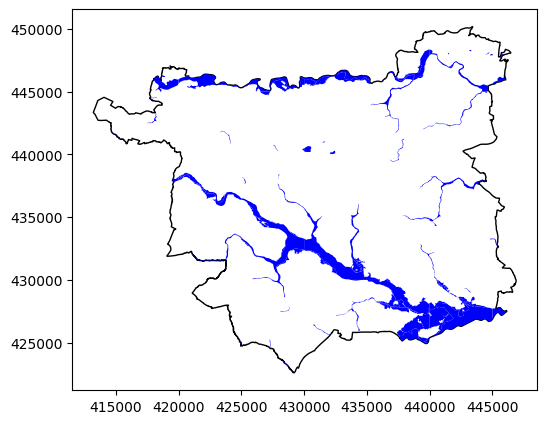

In [315]:
#Subset data to LA
flooding = gpd.clip(Flood, LA_outline)

#Check
fig , ax = plt.subplots(figsize=(6, 6))

#Plot outline first
LA_outline.plot(
    ax= ax,
    facecolor= 'none',
    edgecolor='black',
    linewidth=1
)

#Plot brown fields
flooding.plot(
    ax=ax,
    color='blue'
)

plt.show()

In [316]:
#Convert CRS to 4326 for mapping on dashboard
print(flooding.crs)
flooding = flooding.to_crs(4326)
print(flooding.crs)

EPSG:27700
EPSG:4326


In [317]:
flooding= flooding[["Class",
                    "Legend",
                    "geometry"]]

In [318]:
#Change the Class to be more explicit for users
flooding['Class']= flooding['Class'].replace({'1 Coastal': 'Coastal - High Flood Potential',
                                              '2 Coastal': 'Coastal - Secondary Flood Potential',
                                              '1 Fluvial': 'Fluvial - High Flood Potential',
                                              '2 Fluvial': 'Fluvial - Secondary Flood Potential',
})

In [319]:
#Save Locally
flooding.to_file((os.path.join(DATA_DIR, "flooding.gpkg")), driver='GPKG')
#Save in workspace
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"
flooding.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "flooding.gpkg")), driver='GPKG')

## 4- Creating PPFI Layer - HASP

The following PPFI (Priority Places for Food Index) data at the LSOA level is downloaded from [HASP](https://data.hasp.ac.uk/browser/dataset/5276/0). There are 482 LSOAs in Leeds.

In [320]:
#Load file
ppfi = pd.read_csv(f'{DATA_DIR}\PPFI_Hasp\hasp_ppfi_v2.1.csv')
ppfi.head()

,lsoa21cd,domain_supermarket_proximity,domain_supermarket_accessibility,domain_ecommerce_access,domain_socio_demographic,domain_nonsupermarket_proximity,domain_food_for_families,domain_fuel_poverty,country,country_denominator,combined,pp_dec_domain_supermarket_proximity,pp_dec_domain_supermarket_accessibility,pp_dec_domain_ecommerce_access,pp_dec_domain_socio_demographic,pp_dec_domain_nonsupermarket_proximity,pp_dec_domain_food_for_families,pp_dec_domain_fuel_poverty,pp_dec_combined
0,95AA01S1,480,NaN,NaN,810,518,760,NaN,NI,890,810,6,NaN,NaN,10,6,9,NaN,10
1,95AA01S2,446,NaN,NaN,789,511,793,NaN,NI,890,807,6,NaN,NaN,9,6,9,NaN,10
2,95AA01S3,435,NaN,NaN,688,291,686,NaN,NI,890,549,5,NaN,NaN,8,4,8,NaN,7
3,95AA02W1,714,NaN,NaN,470,661,237,NaN,NI,890,454,9,NaN,NaN,6,8,3,NaN,6
4,95AA03W1,344,NaN,NaN,218,467,614,NaN,NI,890,242,4,NaN,NaN,3,6,7,NaN,3


There is a need to keep the data only for LSOAs within Leeds. To do this, the boundaries of the Leeds LSOAs are sourced at the same time as collecting data on the Index of Multiple Deprivation (2019) from the [Leeds City Council](https://strategic-planning-leedscc.hub.arcgis.com/apps/90a7de6b7d8146fe9168b9c5c7024b40/explore).

In [321]:
#Data on IMD and LSOA boundaries for Leeds are web scraped
import requests
from shapely.geometry import Polygon, MultiPolygon, shape

url= "https://services1.arcgis.com/brSffcdOV7o1pDVT/arcgis/rest/services/IMD_Join_Ward_HMCA_NP/FeatureServer/0/query"


headers= {
    'User-Agent': 'Mozilla/5.0',
    'Referer': 'https://www.argis.com'
}

#List to store feature rows
all_rows= []
#Control pagination
offset= 0
batch_size= 2000

#Loop through all data
while True:
    params = {
    'where': '1=1', #get everything
    'outFields': '*', #retrun all columns
    'returnGeometry': 'true', #include spatial data (polygons)
    'f': 'geojson', #response format
    'resultOffset': offset,
    'resultRecordCount': batch_size
    }

    #Send request
    response= requests.get(url, params=params, headers=headers)
    response.raise_for_status
    data = response.json()
    print(data.get("crs"))

    #Get list of features
    features = data.get('features', [])
    if not features:
        break
    
    #Loop through features
    for f in features:
        
        row= f['properties']
        geom = f.get('geometry')
        
        row['geometry']= None
        
        if geom:
            try:
                row['geometry']= shape(geom)
            except Exception:
                row['geometry']= None
        else:
            row['geometry']= None
    
        #Store results
        all_rows.append(row)

    offset += batch_size #move to next batch
    print(f'Fetched {offset} records')

#Convert to GeoDataFrame
gdf= pd.DataFrame(all_rows)
Leeds_IMD = gpd.GeoDataFrame(gdf, geometry='geometry', crs='EPSG:4326')

print('Done:', len(Leeds_IMD), 'LSOAs in Leeds')

None
Fetched 2000 records
None
Done: 482 LSOAs in Leeds


In [322]:
Leeds_IMD.head()

,LSOA11CD,LSOA11NM,IMD_Rank,IMD_Decile,Inc_Rank,Inc_Decile,Emp_rank,Emp_decile,EST_Rank,EST_Decile,...,HMCA_area_m,HMCA_pc,Ward_1612255540705,Ward_area_m,Ward_pc,NPA,NPA_area_m,NPA_pc,ObjectId,geometry
0,E01032504,Leeds 007F,31839,10,32402,10,30827,10,31706,10,...,2.974304e+06,100.000000,Adel & Wharfedale,2968851,100,n/a,0,0,1,"POLYGON ((-1.59735 53.871, -1.59735 53.871, -1..."
1,E01032502,Leeds 017F,5044,2,5274,2,4411,2,8621,3,...,4.505404e+05,99.999999,Weetwood,377787,84,n/a,0,0,2,"POLYGON ((-1.62394 53.84245, -1.62397 53.84247..."
2,E01032503,Leeds 007E,25993,8,31711,10,29478,9,28867,9,...,8.729546e+06,67.930330,Otley & Yeadon,8308303,65,AIREBOROUGH,3502781,27,3,"POLYGON ((-1.62293 53.88834, -1.62293 53.88832..."
3,E01032500,Leeds 067H,2248,1,4105,2,4771,2,3831,2,...,1.407281e+05,99.999996,Armley,140728,100,n/a,0,0,4,"POLYGON ((-1.59787 53.79812, -1.59811 53.79809..."
4,E01032501,Leeds 017E,25561,8,24837,8,23813,8,26340,9,...,2.460166e+05,99.999999,Weetwood,175925,72,n/a,0,0,5,"POLYGON ((-1.6295 53.84737, -1.62982 53.84726,..."


In [323]:
Leeds_IMD.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 35 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   LSOA11CD                482 non-null    str     
 1   LSOA11NM                482 non-null    str     
 2   IMD_Rank                482 non-null    int64   
 3   IMD_Decile              482 non-null    int64   
 4   Inc_Rank                482 non-null    int64   
 5   Inc_Decile              482 non-null    int64   
 6   Emp_rank                482 non-null    int64   
 7   Emp_decile              482 non-null    int64   
 8   EST_Rank                482 non-null    int64   
 9   EST_Decile              482 non-null    int64   
 10  HDD_Rank                482 non-null    int64   
 11  HDD_Decile              482 non-null    int64   
 12  Crm_Rank                482 non-null    int64   
 13  Crm_Decile              482 non-null    int64   
 14  BHS_Rank          

In [324]:
print(Leeds_IMD.crs)

EPSG:4326


In [325]:
#Merge and keep the PPFI data only for LSOAs in Leeds, by merging with IMD data
Leeds_PPFI_IMD= Leeds_IMD.merge(
    ppfi,
    left_on= 'LSOA11CD',
    right_on= 'lsoa21cd',
    how='left'
)
Leeds_PPFI_IMD= gpd.GeoDataFrame(Leeds_PPFI_IMD,
                             geometry= 'geometry',
                             crs= Leeds_IMD.crs)
Leeds_PPFI_IMD.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 54 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   LSOA11CD                                 482 non-null    str     
 1   LSOA11NM                                 482 non-null    str     
 2   IMD_Rank                                 482 non-null    int64   
 3   IMD_Decile                               482 non-null    int64   
 4   Inc_Rank                                 482 non-null    int64   
 5   Inc_Decile                               482 non-null    int64   
 6   Emp_rank                                 482 non-null    int64   
 7   Emp_decile                               482 non-null    int64   
 8   EST_Rank                                 482 non-null    int64   
 9   EST_Decile                               482 non-null    int64   
 10  HDD_Rank                      

In [326]:
#Keep only metrics used in dashboard
Leeds_PPFI_IMD= Leeds_PPFI_IMD[['lsoa21cd',
                                'LSOA11Desc',
                                'Ward_1612255540705',
                                
                                'pp_dec_combined', 
                                'pp_dec_domain_supermarket_proximity',
                                'pp_dec_domain_supermarket_accessibility',
                                'pp_dec_domain_socio_demographic',
                                'pp_dec_domain_nonsupermarket_proximity',
                                
                                'IMD_Decile',
                                
                                'geometry']]
Leeds_PPFI_IMD.head()

,lsoa21cd,LSOA11Desc,Ward_1612255540705,pp_dec_combined,pp_dec_domain_supermarket_proximity,pp_dec_domain_supermarket_accessibility,pp_dec_domain_socio_demographic,pp_dec_domain_nonsupermarket_proximity,IMD_Decile,geometry
0,E01032504,"East Bramhope, King Lane, Golden Acre Park (2011)",Adel & Wharfedale,6.0,2.0,4.0,10.0,3.0,10,"POLYGON ((-1.59735 53.871, -1.59735 53.871, -1..."
1,E01032502,"Haigh Woods, Silk Mills, Woodnook Drive (2011)",Weetwood,1.0,3.0,4.0,3.0,4.0,2,"POLYGON ((-1.62394 53.84245, -1.62397 53.84247..."
2,E01032503,"Airport, Cartlon, West Bramhope, (2011)",Otley & Yeadon,7.0,3.0,4.0,10.0,4.0,8,"POLYGON ((-1.62293 53.88834, -1.62293 53.88832..."
3,E01032500,"Armley Ridge Road, Edinburghs (2011)",Armley,1.0,8.0,5.0,1.0,5.0,1,"POLYGON ((-1.59787 53.79812, -1.59811 53.79809..."
4,E01032501,"Tinshill Lane, Carr Bridge Drive (2011)",Weetwood,6.0,3.0,7.0,8.0,4.0,8,"POLYGON ((-1.6295 53.84737, -1.62982 53.84726,..."


In [327]:
Leeds_PPFI_IMD['pp_dec_domain_supermarket_accessibility'].unique()

array([ 4.,  5.,  7.,  6.,  3.,  2.,  9.,  1., 10.,  8., nan])

In [328]:
Leeds_PPFI_IMD.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 482 entries, 0 to 481
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype   
---  ------                                   --------------  -----   
 0   lsoa21cd                                 473 non-null    str     
 1   LSOA11Desc                               482 non-null    str     
 2   Ward_1612255540705                       482 non-null    str     
 3   pp_dec_combined                          473 non-null    float64 
 4   pp_dec_domain_supermarket_proximity      473 non-null    float64 
 5   pp_dec_domain_supermarket_accessibility  473 non-null    float64 
 6   pp_dec_domain_socio_demographic          473 non-null    float64 
 7   pp_dec_domain_nonsupermarket_proximity   473 non-null    float64 
 8   IMD_Decile                               482 non-null    int64   
 9   geometry                                 482 non-null    geometry
dtypes: float64(5), geometry(1), in

Notice: there is an IMD measure for all 482 LSOAs but only 473 have a PPFI measure.

In [329]:
#Convert all of them to integers (currently have a mix of str, float and int)
Leeds_PPFI_IMD['IMD_Decile']= Leeds_PPFI_IMD['IMD_Decile'].astype('Int64')
Leeds_PPFI_IMD['pp_dec_combined']= Leeds_PPFI_IMD['pp_dec_combined'].astype('Int64')
Leeds_PPFI_IMD['pp_dec_domain_supermarket_proximity']= Leeds_PPFI_IMD['pp_dec_domain_supermarket_proximity'].astype('Int64')
Leeds_PPFI_IMD['pp_dec_domain_supermarket_accessibility']= Leeds_PPFI_IMD['pp_dec_domain_supermarket_accessibility'].astype('Int64')
Leeds_PPFI_IMD['pp_dec_domain_socio_demographic']= Leeds_PPFI_IMD['pp_dec_domain_socio_demographic'].astype('Int64')
Leeds_PPFI_IMD['pp_dec_domain_nonsupermarket_proximity']= Leeds_PPFI_IMD['pp_dec_domain_nonsupermarket_proximity'].astype('Int64')

<Axes: >

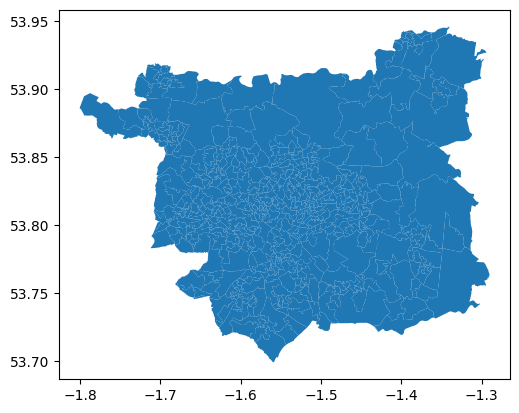

In [330]:
Leeds_PPFI_IMD.plot()

In [331]:
#Save Locally
Leeds_PPFI_IMD.to_file((os.path.join(DATA_DIR, "Leeds_Demo.gpkg")), driver='GPKG')
#Save in workspace
workspace_path= r"C:\Users\qxnq723\Desktop\Project_2\Dashboard Development"
Leeds_PPFI_IMD.to_file((os.path.join(workspace_path, "Data", "Processed_Data", "Leeds_Demo.gpkg")), driver='GPKG')

## 2- Combining OS and OSM data

This section collects and combines green space data from OS and OSm, excluding spaces marked as 'private'.

### A- Ordnance Survey (OS) Green Spaces

The Green Spaces data is downloaded from [Ordnance Survey](https://osdatahub.os.uk/data/downloads/open/OpenGreenspace).
The OS green spaces data is then subsetted to include only green spaces within the chosen local authority (here Leeds). It is then subsetted again to only include spaces that are considered to be potential future CGSs.
Information about definitions of the OS green spaces functions can be found [here](https://docs.os.uk/os-downloads/products/land-and-terrain-portfolio/os-open-greenspace/os-open-greenspace-technical-specification/code-lists/functionvalue).

OS Function | Definition
------------|------------
Public Park Or Garden|Areas of land designed, constructed, managed, and maintained as a public park or garden. These normally have a defined perimeter and free public access, and generally sit within or close to urban areas. Access is granted for a wide range of uses and not usually restricted to paths or tracks within the area. May include areas with managed facilities, such as benches and flowerbeds, and more natural areas.
~~Religious Grounds~~ | ~~Areas of land associated with churches and other places of worship. Only included where there are significant areas of greenspace (over 500m2 of natural space – identified as surfaces that are not manmade, such as grass, woodland and bare earth).~~
~~Cemetery~~|~~Areas of land associated with burial areas.~~



In [332]:
# # Define path to OS green spaces data
# OPGS_PATH = f"{DATA_DIR}\OS_Greenspace_UK\Data\opgrsp_gb.gpkg"

In [333]:
# # Check available layers in the OS Open Greenspace file
# print("Available layers in OS Open Greenspace:")
# layers = fiona.listlayers(OPGS_PATH)
# for layer in layers:
#     print(f"  - {layer}")

In [334]:
# # Load OS Open Greenspace data (this loads all the data - so would not recommend visualising at this stage)
# print("\nLoading OS Open Greenspace data...")
# os_greenspace_access = gpd.read_file(OPGS_PATH, layer='access_point')
# os_greenspace_site = gpd.read_file(OPGS_PATH, layer='greenspace_site')

# print(f"Loaded {len(os_greenspace_access)} access points")
# print(f"Loaded {len(os_greenspace_site)} greenspace sites")

In [335]:
# # Subset OS greenspace data to the target LAD
# print(f"\nSubsetting OS greenspace data to {LOCAL_AUTHORITY_NAME}...")

# greenspace_sites_lad = subset_to_LAD(
#     LAD_gdf=LAD_2024, 
#     LAD_column_name='LAD24NM', 
#     LAD_name=LOCAL_AUTHORITY_NAME, 
#     data_to_subset=os_greenspace_site
# )

# greenspace_access_lad = subset_to_LAD(
#     LAD_gdf=LAD_2024, 
#     LAD_column_name='LAD24NM', 
#     LAD_name=LOCAL_AUTHORITY_NAME, 
#     data_to_subset=os_greenspace_access
# )

# print(f"OS greenspace sites in {LOCAL_AUTHORITY_NAME}: {len(greenspace_sites_lad)}")
# print(f"OS greenspace access points in {LOCAL_AUTHORITY_NAME}: {len(greenspace_access_lad)}")

# # Display sample data
# print("\nSample OS greenspace data:")
# print(greenspace_sites_lad[['id', 'distinctive_name_1', 'function']].head())

In [336]:
# print('Total OS greenspaces in', LOCAL_AUTHORITY_NAME,':', greenspace_sites_lad['id'].nunique())

In [337]:
# #Check CRS
# print(greenspace_sites_lad.crs)

In [338]:
# greenspace_sites_lad.head()

In [339]:
# #Plot OS Greenspaces in Local Authority
# fig , ax = plt.subplots(figsize=(6, 6))

# #Plot outline first
# LA_outline.plot(
#     ax= ax,
#     facecolor= 'none',
#     edgecolor='black',
#     linewidth=1
# )

# #Plot greenspaces
# greenspace_sites_lad.plot(
#     ax=ax,
#     color='green'
# )

# plt.show()

In this section, the OS green spaces with existing Community Growing Schemes are excluded. Only the green spaces which could potentially be developped as CGSs in the future are kept.

In [340]:
# greenspace_sites_lad['function'].value_counts()

In [341]:
# #Keep only spaces with potential to develop for CGSs
# potential_functions = ['Public Park Or Garden']
# os_potential_cgs = greenspace_sites_lad[greenspace_sites_lad['function'].isin(potential_functions)]

In [342]:
# os_potential_cgs.head()

### B- OpenStreetMap API data

The data is collected from the [OpenStreetMap API](https://www.openstreetmap.org).
The map features, corresponding to potential future CGSs are selected from [here](https://wiki.openstreetmap.org/wiki/Map_features).

This article is also useful: https://pythongis.org/part2/chapter-09/nb/00-retrieving-osm-data.html 

OSM Key| Value| Description
-------|----|-------
leisure|garden|A place where flowers and other plants are grown in a decorative and structured manner or for scientific purposes.
leisure|nature_reserve|A protected area of importance for wildlife, flora, fauna or features of geological or other special interest.
leisure|park|A park, usually in an urban (municipal) setting, created for recreation and relaxation.
landuse|forest|Managed forest or woodland plantation. Some use this to map an area of trees rather than the use of the land.
landuse|flowerbed|An area used to grow decorative flowers.
landuse|meadow|A meadow or pasture: land primarily vegetated by grass and non-woody plants, mainly used for hay or grazing.
landuse|brownfield|Describes land scheduled for new development where old buildings have been demolished and cleared.
landuse|cemetary|Place for burials.
landuse|grass|An area of mown and managed grass not otherwise covered by a more specific tag.
landuse|recreation_ground|An open green space for general recreation, which may include pitches, nets and so on, usually municipal but possibly also private to colleges or companies.
landuse|religious|An area used for religious purposes.
landuse|village_green|A village green is a distinctive area of grassy public land in a village centre. Not a generic tag for urban greenery. It is a typical English term – defined separately from 'common land' under the Commons Registration Act 1965 and the Commons Act 2006.
landuse|greenery|Used for any area covered with landscaping or decorative greenery, regardless of it being on a roundabout, along a street or in a park/garden, This tag has been used for vegetation that is hard to classify, either because its kind or because its diversity.
natural|grassland|An area where the vegetation is dominated by grasses and other herbaceous (non-woody) plants.
natural|heath|A dwarf-shrub habitat, characterised by open, low growing woody vegetation, often dominated by plants of the Ericaceae.
natural|scrub|Uncultivated land covered with shrubs, bushes or stunted trees.
natural|shrubbery|An area of woody shrubbery that is actively maintained or pruned by humans. A slightly wilder look is also possible.
natural|wood|Tree-covered area (a 'forest' or 'wood').
man_made|flowerbed|An area designated for flowers.
man_made|planter|A raised structure for planting flowers or other ornamental plants.

In [343]:
# # Define OSM tags for existing CGSs
# import osmnx as ox

# osm_tags = {
#     'leisure': ['garden',
#                 'nature_reserve',
#                 'park'],
#     'landuse': ['forest',
#                 'flowerbed',
#                 'meadow',  
#                 'brownfield',
#                 'cemetary',
#                 'grass',
#                 'recreation_ground',
#                 'religious'
#                 #'village_green',
#                 'greenery'
#                 ],
#     'natural': ['grassland',
#                 'heath', 
#                 'scrub',
#                 'shrubbery',
#                 'wood'
#                 ],
#     'man_made': ['flowerbed',
#                  'planter']
# }

# print("Extracting OSM Potential CGS data...")
# print(f"Tags to extract: {osm_tags}")

# # Get the target LAD geometry
# target_lad_geom = LAD_2024.loc[LAD_2024['LAD24NM'] == LOCAL_AUTHORITY_NAME, :]

# try:
#     # Extract OSM features
#     gdf = ox.features_from_polygon(
#         target_lad_geom.to_crs("EPSG:4326").union_all(), 
#         osm_tags
#     )
    
#     filters = [gdf[tag_key].isin(tag_values) 
#            for tag_key, tag_values in osm_tags.items() 
#            if tag_key in gdf.columns]

#     osm_potential_cgs = gdf[pd.concat(filters, axis=1).any(axis=1)].reset_index() if filters else gpd.GeoDataFrame()
    
#     print(f"Extracted {len(osm_potential_cgs)} OSM Potential CGSs features in {LOCAL_AUTHORITY_NAME}")
    
#     # Display sample data
#     print("\nSample OSM Potential CGS data:")
#     available_cols = [col for col in ['name', 'leisure', 'landuse', 'natural'] if col in osm_potential_cgs.columns]
#     print(osm_potential_cgs[available_cols].head())
    
# except Exception as e:
#     print(f"Error extracting OSM data: {e}")
#     osm_potential_cgs = gpd.GeoDataFrame()

In [344]:
# osm_potential_cgs.info()

### C- Combining OSM and OS data

Cleaning and data prep.

In [345]:
# # Tidy OS names 
# os_potential_cgs['Other name(s) (OS)']= os_potential_cgs[['distinctive_name_2','distinctive_name_3','distinctive_name_4']].apply(lambda x: ', '.join(x[x.notnull()]), axis = 1).replace(r'^\s*$', np.nan, regex=True)
# os_potential_cgs['Other name(s) (OS)'].unique()

In [346]:
# # Clean osm data to remove green spaces/CGSs marked as private
# osm_potential_cgs = osm_potential_cgs.loc[osm_potential_cgs['access']!='private',:]


# # Define OS 'function' equivalent for OSM data
# osm_potential_cgs['Type (OSM)'] = osm_potential_cgs[['leisure', 'landuse', 'natural', 'man_made']].apply(
#         lambda x: ', '.join(sorted(x.dropna().astype(str))), axis=1
#     )

# osm_potential_cgs['Type (OSM)'].value_counts()

Combine data

In [347]:
# # Combine OS and OSM data into one df

# if len(osm_potential_cgs) > 0:
#     # Prepare OS CGS data for joining
#     os_gs_to_join = os_potential_cgs[['distinctive_name_1', 'Other name(s) (OS)','function', 'id', 'geometry']].copy()
#     os_gs_to_join['flag_OS'] ='OS'
#     os_gs_to_join.columns = ['Name (OS)', 'Other name(s) (OS)','Type (OS)', 'OS ID', 'geometry','flag_OS']
    
#     # Prepare OSM CGS data for joining
#     # Combine OSM tags into one value
#     osm_potential_cgs['Type (OSM)'] = osm_potential_cgs[['leisure', 'landuse', 'natural', 'man_made']].apply(
#         lambda x: ', '.join(sorted(x.dropna().astype(str))), axis=1
#     )

#     # Select relevant columns for OSM data
    
#     osm_cols = ['name', 'alt_name','Type (OSM)', 'osmid', 'geometry','flag_OSM']
#     available_osm_cols = [col for col in osm_cols if col in osm_potential_cgs.columns]
#     osm_gs_to_join = osm_potential_cgs[available_osm_cols].copy()
#     osm_gs_to_join['flag_OSM'] ='OSM'
#     # Ensure we have the right column names
#     if 'name' in osm_gs_to_join.columns:
#         osm_gs_to_join = osm_gs_to_join.rename(columns={'name': 'Name (OSM)'})
#     else:
#         osm_gs_to_join['Name (OSM)'] = None
        
#     if 'osmid' in osm_gs_to_join.columns:
#         osm_gs_to_join = osm_gs_to_join.rename(columns={'osmid': 'OSM ID'})
#     else:
#         osm_gs_to_join['OSM ID'] = None
    
#     if 'alt_name' in osm_gs_to_join.columns:
#         osm_gs_to_join = osm_gs_to_join.rename(columns={'alt_name': 'Other name(s) (OSM)'})
#     else:
#         osm_gs_to_join['Other name(s) (OSM)'] = None
#     # Ensure both datasets have the same CRS
#     osm_gs_to_join = osm_gs_to_join.to_crs(os_gs_to_join.crs)

#     # Combine OS and OSM data
#     print("Combining OS and OSM Potential CGS data...")
#     combined_potential_cgs = pd.concat([os_gs_to_join, osm_gs_to_join], ignore_index=True)
    
#     # Create a unified flag for the data origin and remove temp flag columns 
#     combined_potential_cgs['flag']= combined_potential_cgs['flag_OS'].fillna(combined_potential_cgs['flag_OSM'])
#     combined_potential_cgs= combined_potential_cgs.drop(columns={'flag_OS','flag_OSM'})
    
#     print(f"Combined dataset: {len(combined_potential_cgs)} features")
#     print(f"  - OS features: {len(os_gs_to_join)}")
#     print(f"  - OSM features: {len(osm_gs_to_join)}")
    
# else:
#     print("No OSM data available, using only OS data")
#     combined_potential_cgs = os_gs_to_join.copy()